# Install and import

In [ ]:
!pip install torch-geometric


In [2]:
import pandas as pd
import numpy as np

from datetime import timedelta

import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATv2Conv
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve





# Data - 5elem

## UNSW1

In [4]:
data_unsw1 = pd.read_csv('/content/UNSW-NB15_1.csv', dtype={'sport': object, 'dsport': object}, low_memory=False)

columnas = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl",
    "dttl", "sloss", "dloss", "service", "sload", "dload", "spkts", "dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat", "is_sm_ips_ports",
    "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst",
    "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label"
]

data_unsw1.columns = columnas


# Convert 'stime' and 'ltime' to datetime format
data_unsw1['stime'] = pd.to_datetime(data_unsw1['stime'], unit='s')
data_unsw1['ltime'] = pd.to_datetime(data_unsw1['ltime'], unit='s')


# Filter connections lasting less than a second
filtered_unsw1 = data_unsw1[data_unsw1['dur'] <= 1]


# Filter connections from the first 110 minutes (that's where there are malicios connections)
# And select columns of interest
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']]

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

<ipython-input-5-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


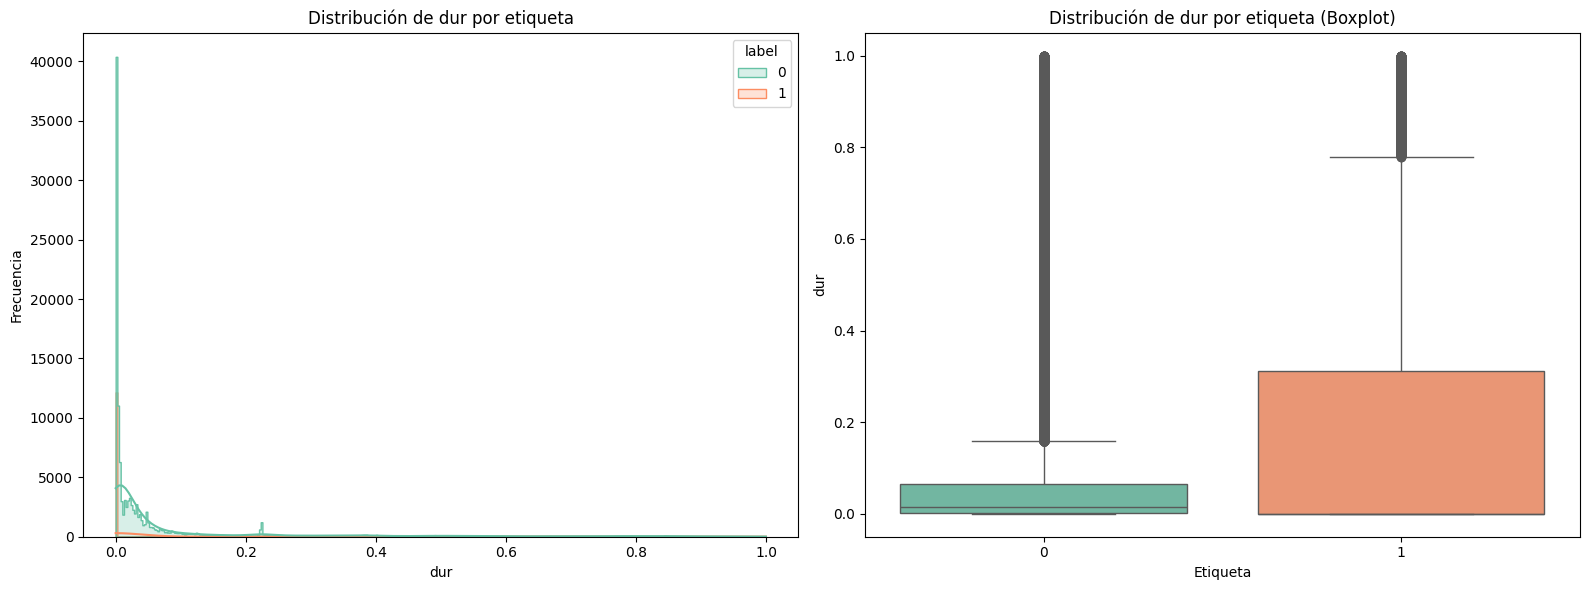

<ipython-input-5-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


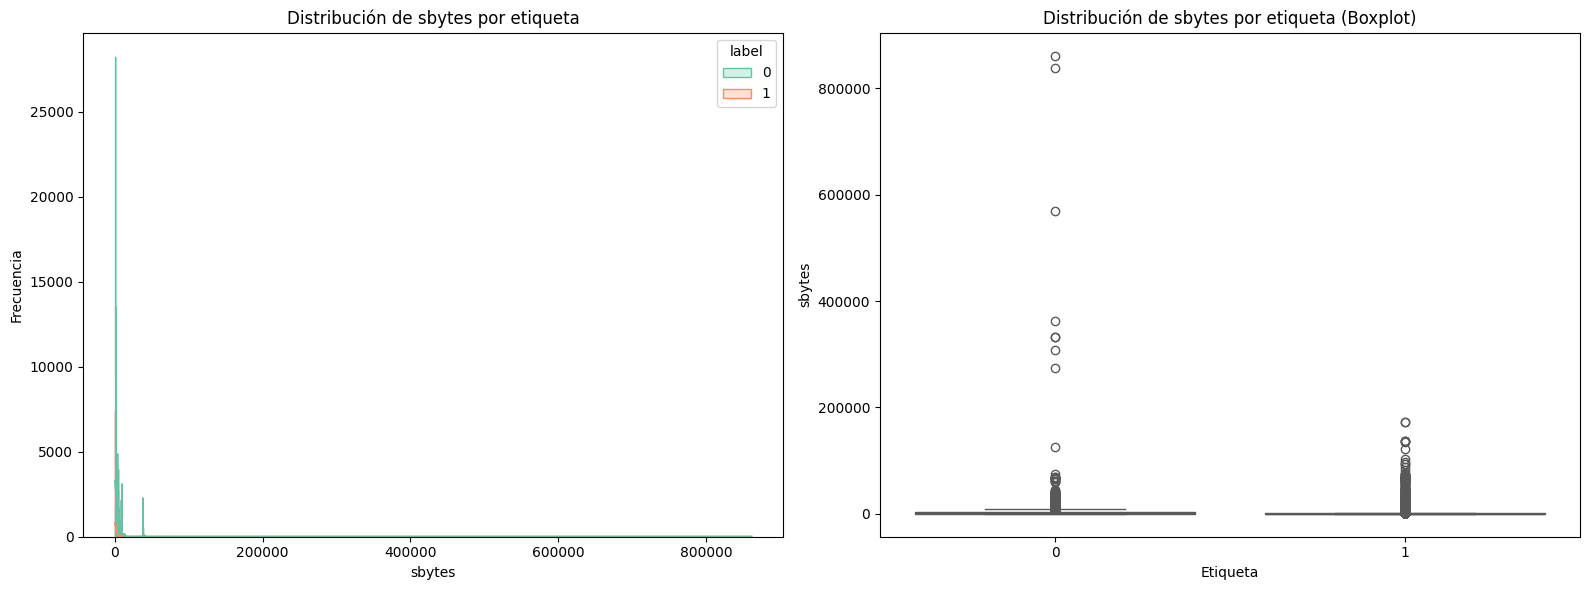

<ipython-input-5-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


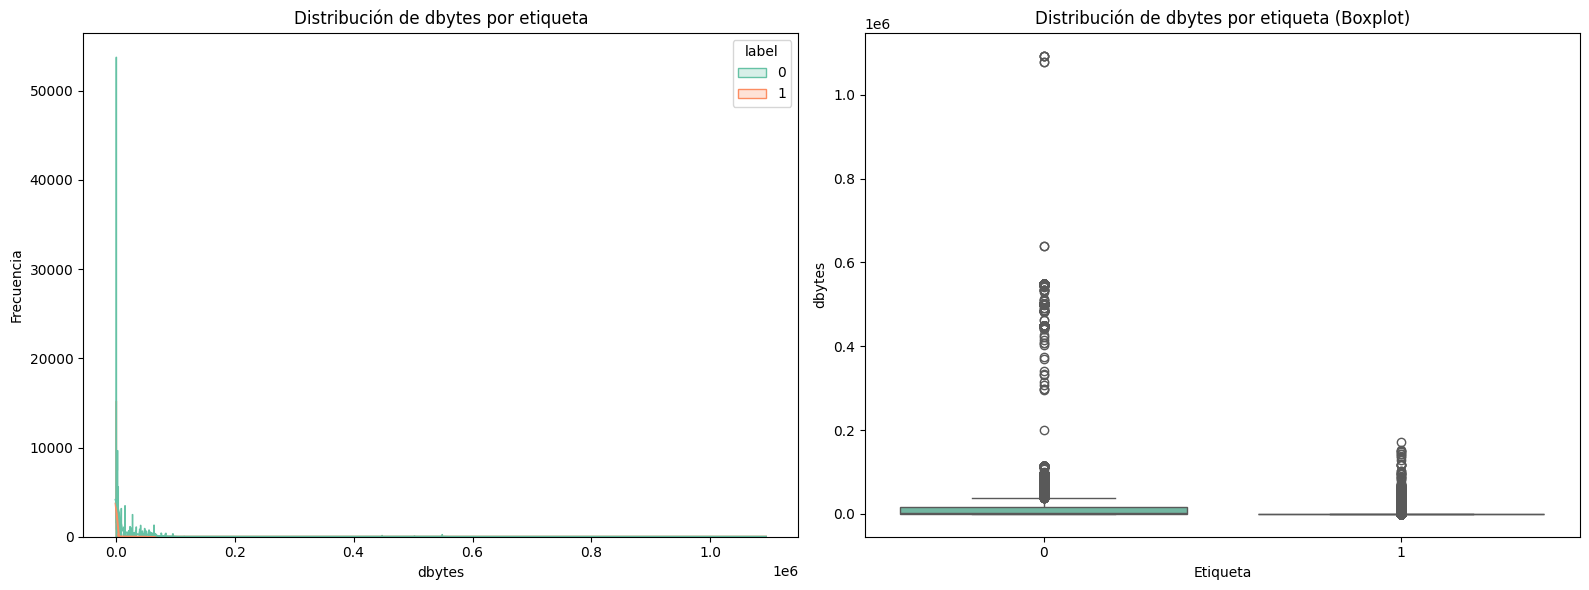

<ipython-input-5-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


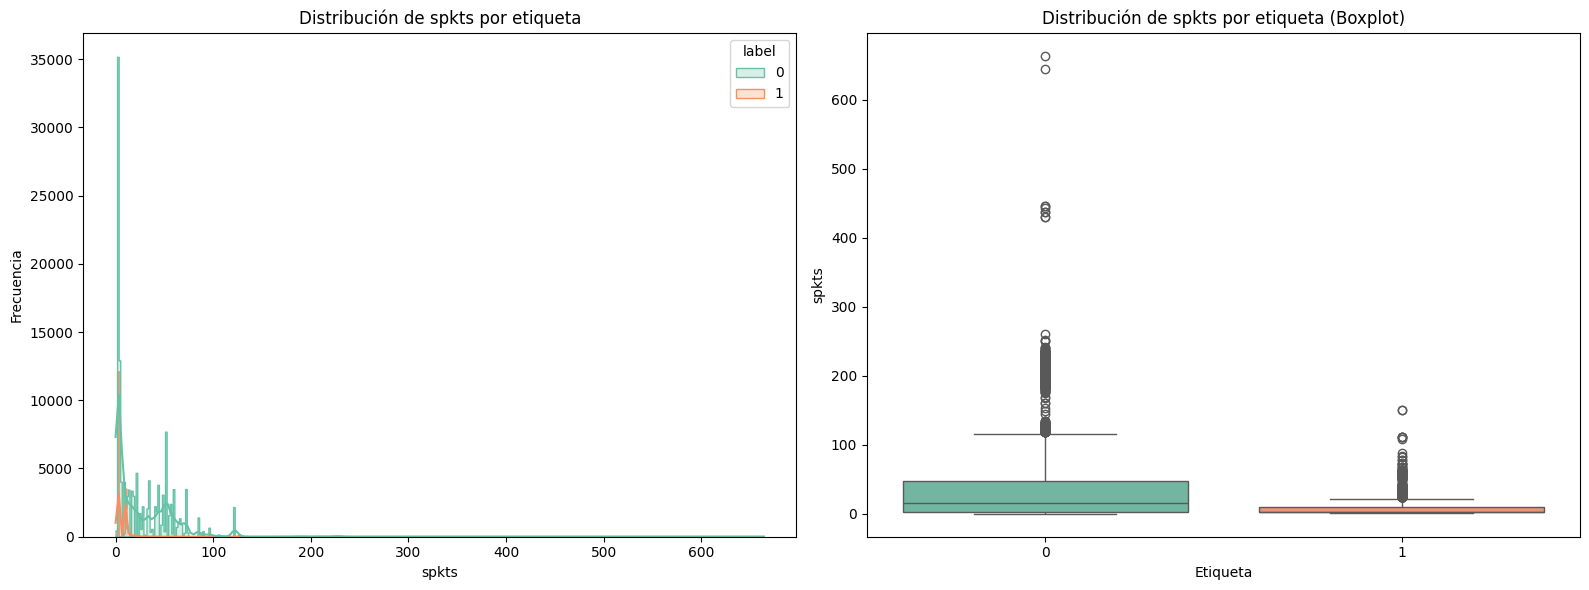

<ipython-input-5-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


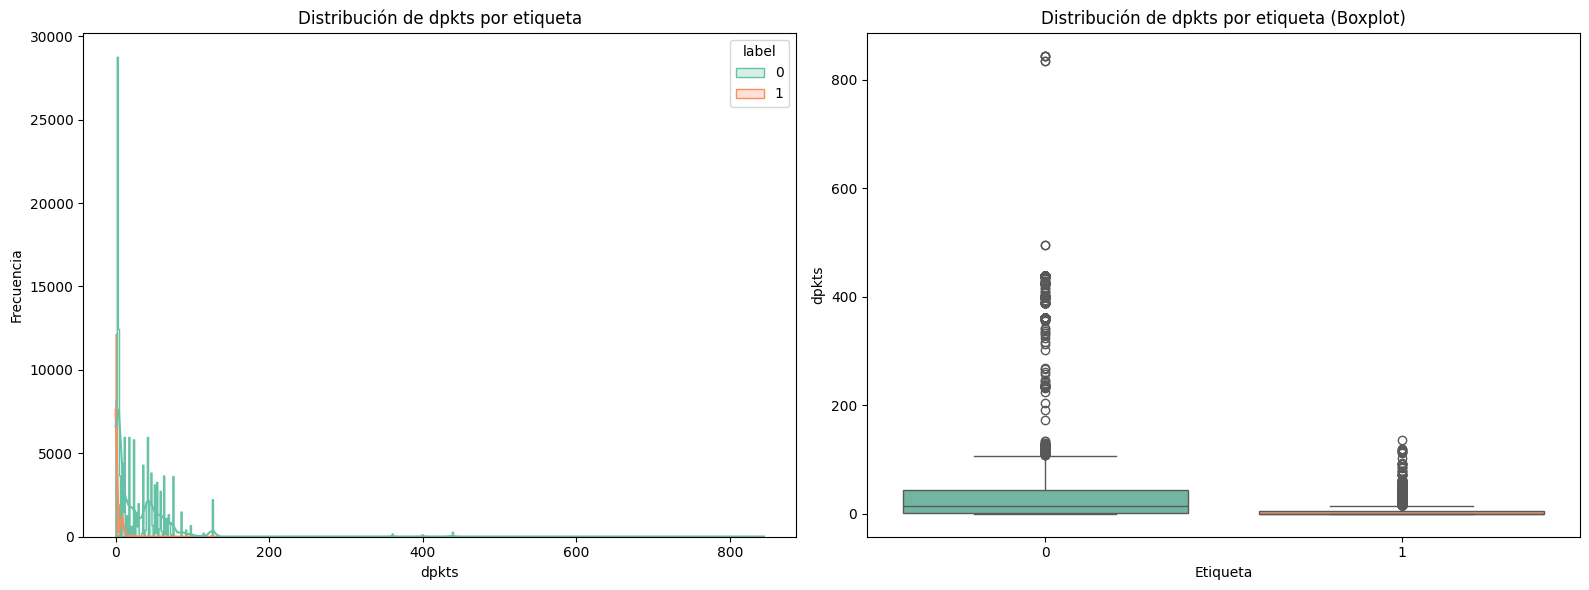

Resumen estadístico de características por etiqueta:
label                    0              1
dur    count  1.305730e+05   17608.000000
       mean   9.488784e-02       0.175307
       std    1.906514e-01       0.292152
       min    0.000000e+00       0.000000
       25%    1.121000e-03       0.000006
       50%    1.497400e-02       0.000011
       75%    6.410800e-02       0.311837
       max    9.999110e-01       0.999796
sbytes count  1.305730e+05   17608.000000
       mean   3.718792e+03    1204.853192
       std    8.694820e+03    6256.533036
       min    0.000000e+00      24.000000
       25%    2.640000e+02     114.000000
       50%    1.540000e+03     200.000000
       75%    3.614000e+03     670.000000
       max    8.613960e+05  172777.000000
dbytes count  1.305730e+05   17608.000000
       mean   1.541560e+04     924.620400
       std    4.278509e+04    6320.789724
       min    0.000000e+00       0.000000
       25%    1.780000e+02       0.000000
       50%    2.262000e

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame temporal para análisis
snapshot_data = unsw1.copy()  # Asegúrate de usar el conjunto preprocesado `unsw1`

# Seleccionar columnas relevantes
features_to_plot = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']  # Características más importantes
labels = snapshot_data['label']  # Etiqueta

# Crear histogramas y boxplots por característica y etiqueta
for feature in features_to_plot:
    plt.figure(figsize=(16, 6))

    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(data=snapshot_data, x=feature, hue='label', kde=True, palette='Set2', element='step')
    plt.title(f'Distribución de {feature} por etiqueta')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')
    plt.title(f'Distribución de {feature} por etiqueta (Boxplot)')
    plt.xlabel('Etiqueta')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

# Resumen estadístico
print("Resumen estadístico de características por etiqueta:")
summary_stats = snapshot_data.groupby('label')[features_to_plot].describe().transpose()
print(summary_stats)


Filtro: quito las conexiones que duran 0 segundos

In [6]:
# Filter connections lasting less than a second
filtered_unsw1 = data_unsw1[(data_unsw1['dur']>0) & (data_unsw1['dur'] <= 1)]


# Filter connections from the first 110 minutes (that's where there are malicios connections)
# And select columns of interest
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']]

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

### Option 1: Nodes = (ip, port)

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3) # Snapshots every 3 minutes

start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()  # Limpia espacios en 'ip'
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()  # Asegura que 'port' es cadena
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport']).agg({        # AGREGO puerto, pero no se como considerar el protocolo
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport']).agg({        # AGREGO puerto, pero no se como considerar el protocolo
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot

#graph_snapshots = {i: Data(x=node_features_pad, edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}
torch_geo_graphs_unsw1 = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

### Option 2: Nodes = (ip,port,proto) - Features de los edges

In [7]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    # src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
    #     'spkts': 'mean',
    #     'sbytes': 'mean'
    # }).reset_index()
    # src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    # src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    # dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
    #     'dpkts': 'mean',
    #     'dbytes': 'mean'
    # }).reset_index()
    # dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    # dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    # nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    # nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    # nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)

    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'sbytes': 'mean',
        'dbytes': 'mean',
        'spkts': 'mean',
        'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    #edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    #node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

### Option 2': Nodes = (ip, port, proto) - Features de los nodos

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
div_prop=0
for i in range(len(torch_geo_graphs_unsw1_proto)):
  sum_norm=0
  sum_bot=0
  for j in range(len(torch_geo_graphs_unsw1_proto[i].y)):
    if torch_geo_graphs_unsw1_proto[i].y[j]==0:
      sum_norm+=1
    else:
      sum_bot+=1
  div_prop+= (sum_norm/sum_bot)
  print(i,sum_norm,sum_bot,sum_norm/sum_bot)

print(div_prop/36)

0 2510 136 18.455882352941178
1 3249 257 12.642023346303501
2 3276 238 13.764705882352942
3 4094 61 67.11475409836065
4 4198 118 35.57627118644068
5 3602 183 19.683060109289617
6 3737 190 19.66842105263158
7 3369 225 14.973333333333333
8 3295 200 16.475
9 3048 168 18.142857142857142
10 3178 227 14.0
11 3129 213 14.690140845070422
12 3413 246 13.873983739837398
13 3426 207 16.55072463768116
14 3516 152 23.13157894736842
15 3669 235 15.61276595744681
16 3383 178 19.00561797752809
17 3481 145 24.00689655172414
18 3231 345 9.365217391304348
19 3283 166 19.77710843373494
20 3160 271 11.660516605166052
21 3293 195 16.887179487179488
22 3347 168 19.922619047619047
23 3293 182 18.093406593406595
24 3347 175 19.125714285714285
25 3441 170 20.241176470588236
26 3095 238 13.004201680672269
27 3157 206 15.325242718446601
28 3170 176 18.011363636363637
29 3201 230 13.917391304347825
30 3339 164 20.359756097560975
31 3641 133 27.37593984962406
32 3459 109 31.73394495412844
33 3303 166 19.89759036144

In [ ]:
pairs1 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[1].edge_index.T.tolist())

for i in range(len(torch_geo_graphs_unsw1_proto)):
  pairs2 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[i].edge_index.T.tolist())
  print(i,len(pairs1.intersection(pairs2)),len(pairs1.intersection(pairs2))/len(torch_geo_graphs_unsw1_proto[i].y))

0 3 0.0011337868480725624
1 3506 1.0
2 2 0.0005691519635742744
3 6 0.001444043321299639
4 6 0.0013901760889712697
5 11 0.002906208718626156
6 8 0.002037178507766743
7 6 0.001669449081803005
8 4 0.0011444921316165952
9 7 0.0021766169154228856
10 7 0.0020558002936857563
11 8 0.0023937761819269898
12 4 0.0010931948619841486
13 2 0.0005505092210294523
14 5 0.0013631406761177754
15 5 0.0012807377049180327
16 5 0.0014040999719180005
17 2 0.0005515719801434088
18 1 0.0002796420581655481
19 3 0.0008698173383589446
20 3 0.0008743806470416788
21 4 0.0011467889908256881
22 4 0.0011379800853485065
23 6 0.0017266187050359713
24 7 0.0019875070982396364
25 2 0.0005538631957906397
26 8 0.0024002400240024004
27 3 0.0008920606601248885
28 3 0.0008965929468021519
29 5 0.001457301078402798
30 5 0.0014273479874393378
31 3 0.000794912559618442
32 3 0.0008408071748878924
33 2 0.0005765350245027386
34 9 0.002563372258615779
35 2 0.0005720823798627002


In [ ]:
unsw1.keys

## UNSW2 (not available)

In [ ]:
# data_unsw2 = pd.read_csv('/content/UNSW-NB15_2.csv', low_memory=False)
# data_unsw2.columns = columnas

# data_unsw2['stime'] = pd.to_datetime(data_unsw2['stime'], unit='s')
# data_unsw2['ltime'] = pd.to_datetime(data_unsw2['ltime'], unit='s')

# # Filter connections lasting less than a second
# filtered_unsw2 = data_unsw2[data_unsw2['dur'] <= 1]

# start_time = data_unsw2['stime'].min() + timedelta(minutes=628*60)
# end_time = start_time + timedelta(minutes=4*60)

# unsw2_sub = filtered_unsw2[(filtered_unsw2['stime'] >= start_time) & (filtered_unsw2['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']]
# unsw2_sub.replace('-', pd.NA, inplace=True)

# # Drop rows with NaN values
# unsw2 = unsw2_sub.dropna()

## Generate sliding windows

In [ ]:
def generate_sliding_windows(graph_snapshots, num_snapshots_train, window_size, generate_val=False):

    windows_input_train= []

    for t in range(num_snapshots_train - window_size + 1):
        window = []
        for t_key in range(t, t + window_size):
            window.append(graph_snapshots[t_key])
        windows_input_train.append(window)

    if generate_val:
        windows_input_val= []
        num_snapshots_val = len(graph_snapshots) - num_snapshots_train

        for t in range(num_snapshots_val - window_size +1 ):
            window = []
            for t_key in range(num_snapshots_train + t, num_snapshots_train + t + window_size):
                window.append(graph_snapshots[t_key])
            windows_input_val.append(window)

        return windows_input_train, windows_input_val

    else:
        return windows_input_train



In [ ]:
windows_input_train, windows_input_val = generate_sliding_windows(torch_geo_graphs_unsw1_proto, 28, 4, True)

# Models

## GNN traditional

In [9]:
class GNN_traditional(torch.nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2):
        super(GNN_traditional, self).__init__()
        self.conv1 = SAGEConv(node_input_dim, hidden_dim1)
        self.conv2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.conv1 = GCNConv(node_input_dim, hidden_dim1)
        #self.conv2 = GCNConv(hidden_dim1, hidden_dim2)
        self.fc = torch.nn.Linear(hidden_dim2 * 2 + edge_input_dim, 1)  # Combine both nodes + edge_attr

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        #print(f"input:{x.shape}")
          # x is shape (num_nodes_in_snapshot, node_input_dim)

        x = self.conv1(x, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
        #print(f"x after first gnn:{x.shape}")
        x = self.conv2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)
        #print(f"x after seconf gnn:{x.shape}")

        # Combine node representations with edge features
        src_nodes = edge_index[0]  # Source nodes of edges
        dst_nodes = edge_index[1]  # Destination nodes of edges
        edge_features = torch.cat([x[src_nodes], x[dst_nodes], edge_attr], dim=1) # (num_edges_in_snapshot, 2*hidden_dim2 + edge_input_dim)
        #print(f"edge_features:{edge_features.shape}")

        predictions = self.fc(edge_features)
        #print(f"predictions:{predictions.shape}")

        return predictions





## GNN temporal: classifies edges of the last snapshot of a sequence

###  Original version

Devuelve predicciones para el último snapshot de la secuencia

In [ ]:
class EdgeClassificationModel(nn.Module):
    def __init__(self, seq_len, node_input_dim, edge_input_dim, hidden_dim, output_dim):
        super(EdgeClassificationModel, self).__init__()
        self.seq_len = seq_len
        self.node_input_dim = node_input_dim
        self.edge_input_dim = edge_input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        # GNN layer (usada para procesar cada snapshot)
        #self.gnn1 = GCNConv(node_input_dim, hidden_dim)  # Capa GNN
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim)
        self.gnn2 = SAGEConv(hidden_dim, hidden_dim)

        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim + edge_input_dim, hidden_dim, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_dim, output_dim)


    def forward(self, snapshots):
        """
        snapshots: Tensor de forma (batch_size, seq_len, num_nodes, node_features)
        """

        max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            x, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x is shape (num_nodes_in_snapshot, node_input_dim)

            num_edges = edge_index.shape[1]

            #x = self.gnn(x, edge_index)
            x = F.relu(self.gnn1(x, edge_index))
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], edge_attr], dim=1) # (num_edges, 2*hidden_dim + edge_input_dim)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        # Procesar secuencia con GRU
        gru_out, _ = self.gru(edge_embeddings_seq)  # (max_num_edges, seq_len, hidden_dim)

        #gru_output_flat = gru_out.reshape(-1, gru_out.shape[-1])  # (max_num_edges * seq_len, hidden_dim)

        # Predecir etiquetas de aristas en el último snapshot
        final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_dim)

        # Obtenemos las predicciones para cada snapshot
        #predictions = self.edge_predictor(gru_output_flat).view(max_num_edges, len(snapshots), -1)  # (max_num_edges, seq_len, output_dim)

        # Obtenemos las predicciones para el ultimo snapshot
        predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, output_dim)

        return predictions



### Version that modifies traditional

Agrega además dropout

In [ ]:
class EdgeClassificationModel_asTraditional(nn.Module):
    def __init__(self, seq_len, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2, hidden_size_gru):
        super(EdgeClassificationModel_asTraditional, self).__init__()
        #self.gnn1 = GCNConv(node_input_dim, hidden_dim)  # Capa GNN
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim1)
        self.gnn2 = SAGEConv(hidden_dim1, hidden_dim2)
        self.dropout = nn.Dropout(0.5)


        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim2 + edge_input_dim, hidden_size_gru, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots):
        """
        snapshots:
        """

        max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            x, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x is shape (num_nodes_in_snapshot, node_input_dim)

            num_edges = edge_index.shape[1]

            #x = self.gnn1(x, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
            x = self.dropout(F.relu(self.gnn1(x, edge_index)))
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], edge_attr], dim=1) # (num_edges, 2*hidden_dim2 + edge_input_dim)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim2 + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim2 + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim2 + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        # Procesar secuencia con GRU
        gru_out, _ = self.gru(edge_embeddings_seq)  # (max_num_edges, seq_len, hidden_size_gru)

        # Predecir etiquetas de aristas en el último snapshot
        final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, 1)

        return predictions



Otro intento usando máscaras

In [ ]:
class EdgeClassificationModel_asTraditional2(nn.Module):
    def __init__(self, seq_len, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2, hidden_size_gru):
        super(EdgeClassificationModel_asTraditional2, self).__init__()
        #self.gnn1 = GCNConv(node_input_dim, hidden_dim)  # Capa GNN
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim1)
        self.gnn2 = SAGEConv(hidden_dim1, hidden_dim2)

        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim2 + edge_input_dim, hidden_size_gru, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots):
        """
        snapshots:
        """

        max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        masks = []
        for t in range(len(snapshots)):
            x, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x is shape (num_nodes_in_snapshot, node_input_dim)

            num_edges = edge_index.shape[1]

            x = self.gnn1(x, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], edge_attr], dim=1) # (num_edges, 2*hidden_dim2 + edge_input_dim)
            print(f"edge_embeddings:{edge_embeddings.shape}")

            mask = torch.cat([torch.ones(num_edges), torch.zeros(max_num_edges - num_edges)]).to(edge_embeddings.device)
            print(f"mask:{mask.shape}")
            masks.append(mask)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim2 + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim2 + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim2 + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        print(f"edge_embeddings_seq:{edge_embeddings_seq.shape}")
        masks = torch.stack(masks, dim=1)  # (max_num_edges, seq_len)
        print(f"masks:{masks.shape}")


        # Procesar secuencia con GRU
        gru_out_aux, _ = self.gru(edge_embeddings_seq)  # (max_num_edges, seq_len, hidden_size_gru)
        print(f"gru_out_aux:{gru_out_aux.shape}")

        # Aplicar máscara
        gru_out = gru_out_aux * masks.unsqueeze(-1)  # Ignorar padding multiplicando por 0
        print(f"gru_out:{gru_out.shape}")

        # Tomar el último estado válido
        last_valid_indices = masks.sum(dim=1).long() - 1  # Posiciones del último paso válido
        print(f"last_valid_indices:{last_valid_indices.shape}")
        final_node_embeddings = gru_out[range(max_num_edges), last_valid_indices, :]  # Últimos embeddings
        print(f"final_node_embeddins:{final_node_embeddings.shape}")
        predictions = self.edge_predictor(final_node_embeddings)
        print(f"predictions:{predictions.shape}")

        # Predecir etiquetas de aristas en el último snapshot
        # final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        # predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, 1)

        return predictions,masks



In [ ]:
model0=EdgeClassificationModel_asTraditional2(4,4,1,32,16,33)
pred0,masks0=model0(windows_input_train[0])

edge_embeddings:torch.Size([2646, 33])
mask:torch.Size([4155])
edge_embeddings:torch.Size([3506, 33])
mask:torch.Size([4155])
edge_embeddings:torch.Size([3514, 33])
mask:torch.Size([4155])
edge_embeddings:torch.Size([4155, 33])
mask:torch.Size([4155])
edge_embeddings_seq:torch.Size([4155, 4, 33])
masks:torch.Size([4155, 4])
gru_out_aux:torch.Size([4155, 4, 33])
gru_out:torch.Size([4155, 4, 33])
last_valid_indices:torch.Size([4155])
final_node_embeddins:torch.Size([4155, 33])
predictions:torch.Size([4155, 1])


In [ ]:
masks0.sum(dim=1).long() - 1

tensor([3, 3, 3,  ..., 0, 0, 0])

In [ ]:
masks0.shape

torch.Size([4155, 4])

# Train and test

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Model 1: traditional

NOTA: imprimo F1 y AUC para los datos de **training**. Al parecer no está aprendiendo.

In [11]:
model1 = GNN_traditional(node_input_dim=1, edge_input_dim=5, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01) # EN ESTE CASO CONVIENE lr=0.01

#ratio_neg_to_pos = 2
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28)) #30
val_windows = list(range(31,36))#28,36)) #30,39


# Train
epochs = 75
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        optimizer.zero_grad()
        out = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        probabilities = torch.sigmoid(out)
        preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1.eval()
    val_loss = 0
    total_val_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto[window].to(device)
            out = model1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            # probabilities = torch.sigmoid(out)
            # preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            # all_preds_m1.extend(preds)
            # all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/75, Train Loss: 16.1186, Val Loss: 5.0700, ROC-AUC: 0.4953174627761603, F1:0.0402657939105425
Epoch 2/75, Train Loss: 8.7321, Val Loss: 2.9394, ROC-AUC: 0.5973340421579765, F1:0.2874266450243476
Epoch 3/75, Train Loss: 6.6499, Val Loss: 2.3433, ROC-AUC: 0.6391835630115843, F1:0.3356960031502264
Epoch 4/75, Train Loss: 5.2645, Val Loss: 1.7573, ROC-AUC: 0.6372508470062459, F1:0.3446910492862353
Epoch 5/75, Train Loss: 3.7440, Val Loss: 1.2475, ROC-AUC: 0.6334909380045691, F1:0.3356164383561644
Epoch 6/75, Train Loss: 2.6733, Val Loss: 0.5809, ROC-AUC: 0.5791717912168338, F1:0.23163051084674596
Epoch 7/75, Train Loss: 4.1295, Val Loss: 4.1427, ROC-AUC: 0.5190934973011285, F1:0.08764769065520946
Epoch 8/75, Train Loss: 6.7074, Val Loss: 2.2725, ROC-AUC: 0.5443638858336503, F1:0.15662120545534536
Epoch 9/75, Train Loss: 5.6565, Val Loss: 1.6925, ROC-AUC: 0.5939547552619858, F1:0.2793380140421264
Epoch 10/75, Train Loss: 2.5913, Val Loss: 1.0069, ROC-AUC: 0.6306970972073629, F1:0.31

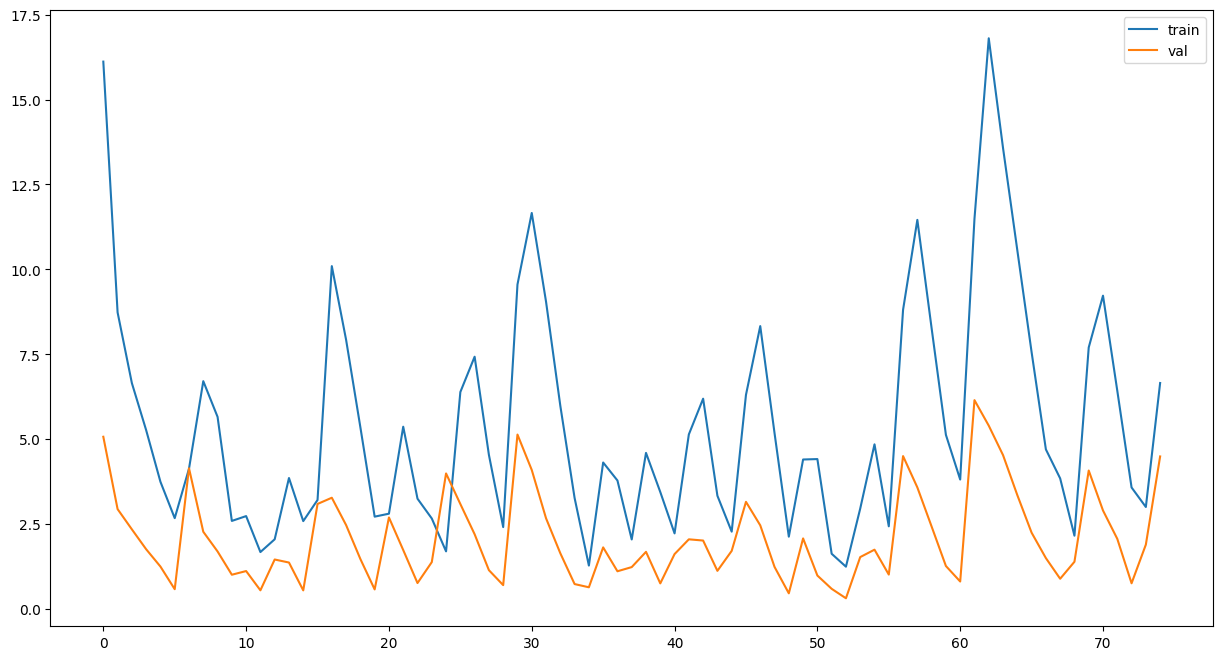

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(75), train_losses_m1, label="train")
axs.plot(range(75), val_losses_m1, label="val")
axs.legend()

NOTA: evalúo en el conjunto de **training**. Malos resultados

In [13]:
# Evaluación validation set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



# without pos_weight - lr=0.001
# ROC-AUC: 0.6696
# Accuracy: 0.4118
# Precision: 0.0653
# Recall: 0.9518
# F1: 0.1223

# pow_weight=15 - lr=0.001
# ROC-AUC: 0.6377
# Accuracy: 0.3090
# Precision: 0.0585
# Recall: 0.9974
# F1: 0.1105



# without pos_weight - lr=0.01
# ROC-AUC: 0.5945
# Accuracy: 0.9508
# Precision: 0.3703
# Recall: 0.2047
# F1: 0.2636

# pos_weight = 15 - lr=0.01
# ROC-AUC: 0.6969
# Accuracy: 0.7821
# Precision: 0.1145
# Recall: 0.6037
# F1: 0.1926

ROC-AUC: 0.4998
Accuracy: 0.9446
Precision: 0.0000
Recall: 0.0000
F1: 0.0000


In [ ]:
# Evaluación UNSW_NB15_2 --> should be modified
# model1.eval()
# all_preds, all_labels = [], []
# with torch.no_grad():
#     for window in range(len(torch_geo_graphs_unsw2)):
#         data = torch_geo_graphs_unsw2[window].to(device)
#         out = model1(data)
#         probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
#         # Convert probabilities to binary predictions using a threshold
#         preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

#         all_preds.extend(preds)
#         all_labels.extend(data.y.cpu().numpy())

# # Metrics
# roc_auc = roc_auc_score(all_labels, all_preds)
# accuracy = accuracy_score(all_labels, all_preds)
# precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)  # Use 'binary' for binary classification
# recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
# f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

# print(f"ROC-AUC: {roc_auc:.4f}")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1: {f1:.4f}")


## Model 2: temporal that modifies traditional

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score


model2 = EdgeClassificationModel_asTraditional(4,4,1,32,16,64)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001) # IMPORTANTE: NO USAR lr=0.01 (SE QUEDA "TRABADO" Y DEJA DE APRENDER)
#loss_fn = nn.CrossEntropyLoss()

#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 75
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out = model2(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2.eval()
    val_loss = 0
    total_val_edges = 0
    with torch.no_grad():
        for window in range(len(windows_input_val)):
        #for window in val_windows:
            #data = ventanas_input_val[window]#.to(device)
            #labels = ventanas_target_val[window].y
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out = model2(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            #val_loss += loss.item()
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
    val_loss_final = val_loss / total_val_edges
    #val_loss_final = val_loss / len(windows_input_val)
    val_losses_m2.append(val_loss_final)


    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}")


In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(75), train_losses_m2, label="train")
axs.plot(range(75), val_losses_m2, label="val")
axs.legend()

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# PREDICCION DEL ULTIMO SNAPSHOT

model2.eval()
all_preds_m2, all_labels_m2 = [], []
with torch.no_grad():
    for window in range(len(windows_input_train)):
        data = windows_input_train[window]#.to(device)
        labels = windows_input_train[window][-1].y
        out = model2(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2.extend(preds)
        all_labels_m2.extend(labels.cpu().numpy())

# Metrics
roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
accuracy_m2 = accuracy_score(all_labels_m2, all_preds_m2)
precision_m2 = precision_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2 = recall_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)
f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2:.4f}")
print(f"Accuracy: {accuracy_m2:.4f}")
print(f"Precision: {precision_m2:.4f}")
print(f"Recall: {recall_m2:.4f}")
print(f"F1: {f1_m2:.4f}")

# ROC-AUC: 0.7823
# Accuracy: 0.9491
# Precision: 0.4340
# Recall: 0.5997
# F1: 0.5036